# Deep Q-Network (DQN) — Lunar Lander

Implementação **do zero** de um agente DQN para o ambiente `LunarLander-v3` (Gymnasium).
O Gymnasium é usado **apenas como simulador** do ambiente — todo o algoritmo (rede Q,
experience replay, target network, erro de Bellman e otimização) é escrito manualmente
abaixo, sem nenhuma biblioteca de RL pronta.

**Roteiro do notebook**
1. Exploração do ambiente (estados, ações, recompensa, término)
2. Rede Q (aproximador de função)
3. Experience Replay
4. Agente DQN (política ε-greedy, erro de Bellman, target network)
5. Loop de treinamento
6. Experimento comparativo: **DQN completo × sem target network × sem experience replay**
7. Curvas de aprendizado e avaliação da política final

> As respostas conceituais sobre o ambiente e a análise em prosa estão no `README.md`.

## 0. Setup e reprodutibilidade

Fixamos a seed em todas as fontes de aleatoriedade. Isso é essencial: inicialização dos
pesos, amostragem do replay, exploração ε-greedy e a dinâmica do ambiente são estocásticas.
Sem seed fixa as curvas não seriam reproduzíveis e a comparação entre configurações ficaria
injusta (diferenças poderiam vir do acaso e não do componente isolado).

In [1]:
import os, random
from collections import deque, namedtuple
from dataclasses import dataclass, field, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
# Rede pequena (8->128->128->4): 1 thread é o mais rápido na CPU; mais threads só
# adicionam overhead de sincronização e deixam o treino muito mais lento.
torch.set_num_threads(1)

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("torch", torch.__version__, "| gymnasium", gym.__version__)

torch 2.12.1+cpu | gymnasium 1.3.0


## 1. Explorando o ambiente

O `LunarLander-v3` fornece um **estado contínuo de 8 dimensões** e **4 ações discretas**.
Inspecionamos os espaços e damos um passo para ver a estrutura da recompensa.

In [2]:
env = gym.make("LunarLander-v3")
state, info = env.reset(seed=SEED)

print("Espaço de observação:", env.observation_space)
print("  low :", np.round(env.observation_space.low, 2))
print("  high:", np.round(env.observation_space.high, 2))
print("Espaço de ações     :", env.action_space, "->", env.action_space.n, "ações discretas")
print("\nEstado inicial (8 dims):", np.round(state, 3))

labels = ["x (pos horiz)", "y (pos vert)", "vx", "vy",
          "ângulo", "vel. angular", "perna esq. (contato)", "perna dir. (contato)"]
for l, v in zip(labels, state):
    print(f"  {l:24s} = {v:7.3f}")

# um passo acionando o motor principal (ação 2)
ns, r, terminated, truncated, _ = env.step(2)
print("\nApós 1 passo (ação=2, motor principal): reward =", round(float(r), 3),
      "| terminated =", terminated, "| truncated =", truncated)
env.close()

Espaço de observação: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  low : [ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ]
  high: [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ]
Espaço de ações     : Discrete(4) -> 4 ações discretas

Estado inicial (8 dims): [ 0.002  1.418  0.233  0.32  -0.003 -0.053  0.     0.   ]
  x (pos horiz)            =   0.002
  y (pos vert)             =   1.418
  vx                       =   0.233
  vy                       =   0.320
  ângulo                   =  -0.003
  vel. angular             =  -0.053
  perna esq. (contato)     =   0.000
  perna dir. (contato)     =   0.000

Após 1 passo (ação=2, motor principal): reward = -2.497 | terminated = False | truncated = False


**Variáveis de estado** (índices 0–7): posição horizontal `x` e vertical `y`,
velocidades `vx`/`vy`, `ângulo` e `velocidade angular` do módulo, e dois indicadores
booleanos de contato das pernas (esquerda/direita) com o solo.

**Ações**: `0` não fazer nada · `1` acionar motor de orientação esquerdo ·
`2` acionar motor principal (impulso para cima) · `3` acionar motor de orientação direito.

## 2. Rede Q — aproximador de função $Q(s,a)$

Como o espaço de estados é **contínuo e de 8 dimensões**, não há como usar uma tabela
$Q[s,a]$. Usamos uma rede neural (MLP) que recebe o estado e devolve um Q-valor por ação.

**Arquitetura:** `8 → 128 → ReLU → 128 → ReLU → 4`.
- Entrada 8 = dimensão do estado; saída 4 = número de ações (coerência com o ambiente).
- Duas camadas ocultas de 128 dão capacidade suficiente para aproximar uma função suave
  de 8→4 sem exagerar no número de parâmetros.
- ReLU como não-linearidade (barata e estável); **saída linear** porque Q-valores podem
  ser negativos e não têm limite superior fixo.

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_size=8, action_size=4, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_size, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # Q de cada ação (linear)

set_seed(SEED)
print(QNetwork())

QNetwork(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)


## 3. Experience Replay

Guardamos transições $(s, a, r, s', \text{done})$ numa memória circular e amostramos
**lotes uniformemente** para treinar. Isso resolve dois problemas:
- **Correlação temporal**: passos consecutivos são fortemente correlacionados e violam a
  hipótese i.i.d. do gradiente estocástico; amostrar do passado descorrelaciona o lote.
- **Eficiência amostral**: cada transição é reaproveitada várias vezes.

Sem replay, o treino fica instável e sujeito a esquecimento catastrófico (testamos isso no
experimento comparativo).

In [4]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity, batch_size):
        self.memory = deque(maxlen=capacity)
        self.batch_size = batch_size

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self):
        batch = random.sample(self.memory, self.batch_size)
        states      = torch.from_numpy(np.vstack([t.state for t in batch])).float()
        actions     = torch.from_numpy(np.vstack([t.action for t in batch])).long()
        rewards     = torch.from_numpy(np.vstack([t.reward for t in batch])).float()
        next_states = torch.from_numpy(np.vstack([t.next_state for t in batch])).float()
        dones       = torch.from_numpy(np.vstack([t.done for t in batch]).astype(np.uint8)).float()
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)

## 4. Agente DQN

Reúne os componentes. A configuração é parametrizável para permitir as **ablações**:
- `use_replay=False` → aprende online, só na transição mais recente (sem buffer).
- `use_target=False` → o alvo de Bellman é calculado pela própria rede online (sem target net).

**Target network**: uma cópia "congelada" da rede usada para calcular o alvo
$y = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$. Ela estabiliza o treino porque, sem
ela, o alvo se moveria a cada passo perseguindo a própria estimativa (alvo móvel → oscilação/
divergência). Atualizamos a target lentamente por *soft update* (Polyak):
$\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$.

In [5]:
@dataclass
class DQNConfig:
    name: str = "full"
    state_size: int = 8
    action_size: int = 4
    hidden: int = 128
    gamma: float = 0.99       # desconto
    lr: float = 5e-4          # taxa de aprendizado (Adam)
    buffer_size: int = 100_000
    batch_size: int = 64
    tau: float = 5e-3         # soft update do target
    update_every: int = 4
    eps_start: float = 1.0
    eps_end: float = 0.01
    eps_decay: float = 0.995
    use_replay: bool = True   # ablação
    use_target: bool = True   # ablação


class DQNAgent:
    def __init__(self, cfg: DQNConfig):
        self.cfg = cfg
        self.qnet = QNetwork(cfg.state_size, cfg.action_size, cfg.hidden)
        self.target_net = QNetwork(cfg.state_size, cfg.action_size, cfg.hidden)
        self.target_net.load_state_dict(self.qnet.state_dict())
        self.optimizer = optim.Adam(self.qnet.parameters(), lr=cfg.lr)
        self.memory = ReplayBuffer(cfg.buffer_size, cfg.batch_size) if cfg.use_replay else None
        self.t_step = 0
        self.last_loss = 0.0

    def act(self, state, eps):
        # política epsilon-greedy
        if random.random() < eps:
            return random.randrange(self.cfg.action_size)
        s = torch.from_numpy(state).float().unsqueeze(0)
        self.qnet.eval()
        with torch.no_grad():
            q = self.qnet(s)
        self.qnet.train()
        return int(q.argmax(dim=1).item())

    def step(self, state, action, reward, next_state, done):
        if self.cfg.use_replay:
            self.memory.push(state, action, reward, next_state, done)
            self.t_step = (self.t_step + 1) % self.cfg.update_every
            if self.t_step == 0 and len(self.memory) >= self.cfg.batch_size:
                self._learn(self.memory.sample())
        else:  # sem replay: aprende só na transição atual
            batch = (
                torch.from_numpy(np.vstack([state])).float(),
                torch.from_numpy(np.vstack([action])).long(),
                torch.from_numpy(np.vstack([reward])).float(),
                torch.from_numpy(np.vstack([next_state])).float(),
                torch.from_numpy(np.vstack([done]).astype(np.uint8)).float(),
            )
            self._learn(batch)

    def _learn(self, batch):
        states, actions, rewards, next_states, dones = batch
        # Q(s,a) previsto pela rede online
        q_expected = self.qnet(states).gather(1, actions)
        # Alvo de Bellman: r + gamma * max_a' Q(s',a') * (1 - done)
        bootstrap_net = self.target_net if self.cfg.use_target else self.qnet
        with torch.no_grad():
            q_next = bootstrap_net(next_states).max(dim=1, keepdim=True)[0]
            q_target = rewards + self.cfg.gamma * q_next * (1.0 - dones)
        # Erro de Bellman (perda de Huber) e atualização dos pesos
        loss = F.smooth_l1_loss(q_expected, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.qnet.parameters(), 10.0)
        self.optimizer.step()
        self.last_loss = float(loss.item())
        # soft update do target network
        if self.cfg.use_target:
            for tp, p in zip(self.target_net.parameters(), self.qnet.parameters()):
                tp.data.copy_(self.cfg.tau * p.data + (1.0 - self.cfg.tau) * tp.data)

## 5. Loop de treinamento

Para cada episódio: reseta o ambiente, age por ε-greedy, registra a transição, aprende e
decai o ε. Registramos a recompensa por episódio e a **média móvel de 100 episódios**
(critério de "resolvido" do Lunar Lander: média ≥ 200).

In [6]:
@dataclass
class TrainResult:
    config: dict
    scores: list = field(default_factory=list)
    moving_avg: list = field(default_factory=list)
    losses: list = field(default_factory=list)
    solved_episode: int = None

def train(cfg, n_episodes=700, max_t=1000, seed=SEED, solve_score=200.0,
          early_stop=True, verbose=True):
    set_seed(seed)
    env = gym.make("LunarLander-v3")
    env.reset(seed=seed); env.action_space.seed(seed)
    agent = DQNAgent(cfg)
    res = TrainResult(config=asdict(cfg))
    eps = cfg.eps_start
    window = deque(maxlen=100)

    for ep in range(1, n_episodes + 1):
        state, _ = env.reset()
        score = 0.0
        for _ in range(max_t):
            action = agent.act(state, eps)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.step(state, action, reward, next_state, float(terminated))
            state = next_state; score += reward
            if done:
                break
        window.append(score)
        avg = float(np.mean(window))
        res.scores.append(score); res.moving_avg.append(avg); res.losses.append(agent.last_loss)
        eps = max(cfg.eps_end, cfg.eps_decay * eps)
        if verbose and (ep % 50 == 0 or ep == 1):
            print(f"[{cfg.name}] ep {ep:4d} | score {score:8.2f} | média100 {avg:8.2f} | eps {eps:.3f}")
        if res.solved_episode is None and len(window) == 100 and avg >= solve_score:
            res.solved_episode = ep
            print(f"[{cfg.name}] >>> RESOLVIDO no episódio {ep} (média100={avg:.2f})")
            if early_stop:
                break
    env.close()
    return res, agent

def evaluate(agent, n_episodes=20, seed=123):
    env = gym.make("LunarLander-v3"); scores = []
    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i); score = 0.0; done = False
        while not done:
            a = agent.act(state, eps=0.0)
            state, r, term, trunc, _ = env.step(a); done = term or trunc; score += r
        scores.append(score)
    env.close()
    return float(np.mean(scores)), scores

## 6. Experimento comparativo

Treinamos **três configurações** com a **mesma seed** e os **mesmos hiperparâmetros**,
isolando um componente por vez:

| Config | Experience replay | Target network |
|---|---|---|
| `full` | ✅ | ✅ |
| `no_target` | ✅ | ❌ |
| `no_replay` | ❌ | ✅ |

> A `full` usa *early stop* ao resolver (média ≥ 200); as ablações rodam todos os episódios
> para evidenciar a (in)estabilidade. Em CPU o conjunto leva alguns minutos.

In [7]:
configs = [
    DQNConfig(name="full",      use_replay=True,  use_target=True),
    DQNConfig(name="no_target", use_replay=True,  use_target=False),
    DQNConfig(name="no_replay", use_replay=False, use_target=True),
]

results = {}
agents = {}
for cfg in configs:
    early = (cfg.name == "full")
    res, agent = train(cfg, n_episodes=700, seed=SEED, early_stop=early, verbose=True)
    results[cfg.name] = res
    agents[cfg.name] = agent

[full] ep    1 | score  -248.34 | média100  -248.34 | eps 0.995


[full] ep   50 | score   -26.63 | média100  -149.61 | eps 0.778


[full] ep  100 | score   -72.29 | média100  -113.87 | eps 0.606


[full] ep  150 | score   -94.92 | média100   -60.41 | eps 0.471


[full] ep  200 | score     6.58 | média100   -43.34 | eps 0.367


...

[no_replay] ep  500 | score  -116.03 | média100    27.61 | eps 0.082


[no_replay] ep  550 | score    32.75 | média100    23.03 | eps 0.063


[no_replay] ep  600 | score   -28.46 | média100     7.03 | eps 0.049


[no_replay] ep  650 | score    17.30 | média100    17.67 | eps 0.038


[no_replay] ep  700 | score    68.77 | média100    11.11 | eps 0.030


## 7. Curvas de aprendizado

Para cada configuração: recompensa por episódio (linha tênue) e média móvel de 100
(linha cheia). A linha tracejada marca o limiar de "resolvido" (200).

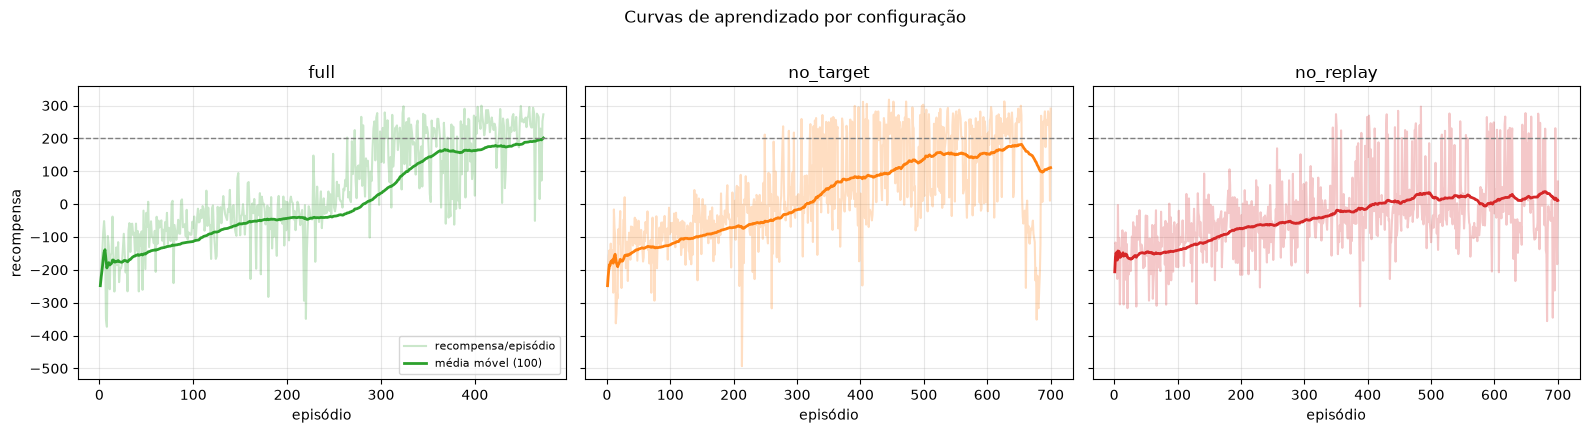

In [8]:
os.makedirs("results", exist_ok=True)
colors = {"full": "tab:green", "no_target": "tab:orange", "no_replay": "tab:red"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, name in zip(axes, ["full", "no_target", "no_replay"]):
    res = results[name]
    x = np.arange(1, len(res.scores) + 1)
    ax.plot(x, res.scores, color=colors[name], alpha=0.25, label="recompensa/episódio")
    ax.plot(x, res.moving_avg, color=colors[name], lw=2, label="média móvel (100)")
    ax.axhline(200, ls="--", color="gray", lw=1)
    ax.set_title(name); ax.set_xlabel("episódio"); ax.grid(alpha=0.3)
axes[0].set_ylabel("recompensa")
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Curvas de aprendizado por configuração", y=1.02)
fig.tight_layout()
fig.savefig("results/curvas_individuais.png", dpi=120, bbox_inches="tight")
plt.show()

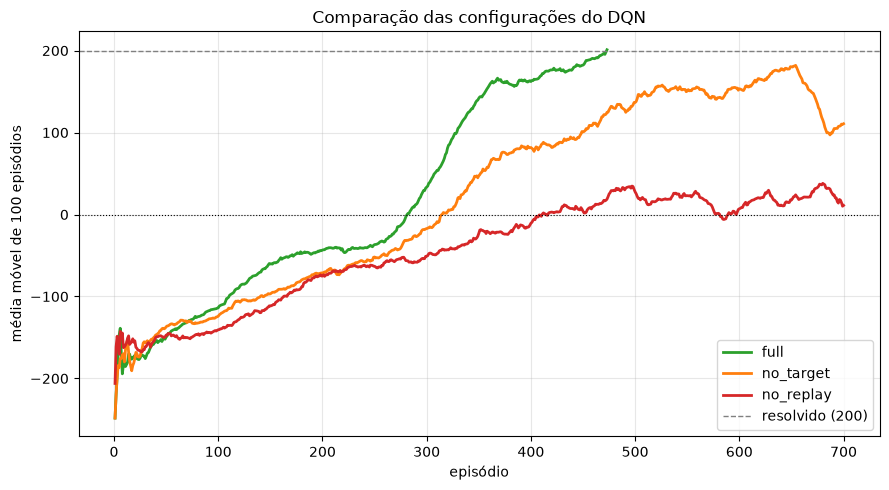

In [9]:
# Comparação direta das médias móveis
plt.figure(figsize=(9, 5))
for name in ["full", "no_target", "no_replay"]:
    res = results[name]
    plt.plot(np.arange(1, len(res.moving_avg) + 1), res.moving_avg,
             color=colors[name], lw=2, label=name)
plt.axhline(200, ls="--", color="gray", lw=1, label="resolvido (200)")
plt.axhline(0, ls=":", color="black", lw=0.8)
plt.xlabel("episódio"); plt.ylabel("média móvel de 100 episódios")
plt.title("Comparação das configurações do DQN"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/curva_comparativa.png", dpi=120, bbox_inches="tight")
plt.show()

### Tabela-resumo e avaliação da política final

Avaliamos cada agente com a **política greedy** (ε=0) em 20 episódios novos — mede o que de
fato foi aprendido, sem exploração aleatória.

In [10]:
rows = []
for name in ["full", "no_target", "no_replay"]:
    res = results[name]
    eval_mean, _ = evaluate(agents[name], n_episodes=20, seed=123)
    rows.append({
        "config": name,
        "episódios": len(res.scores),
        "resolvido_em": res.solved_episode,
        "melhor_média100": round(max(res.moving_avg), 1),
        "média100_final": round(res.moving_avg[-1], 1),
        "avaliação_greedy_20ep": round(eval_mean, 1),
    })
summary = pd.DataFrame(rows).set_index("config")
summary.to_csv("results/summary.csv")
summary

,episódios,resolvido_em,melhor_média100,média100_final,avaliação_greedy_20ep
config,,,,,
full,473,473.0,201.0,201.0,243.5
no_target,700,NaN,182.0,110.7,247.3
no_replay,700,NaN,38.0,11.1,52.7


### Leitura rápida dos resultados

- **`full`** atinge a média ≥ 200 (resolve) e a avaliação greedy confirma pousos consistentes.
- **`no_target`** aprende mais devagar e oscila mais — o alvo móvel degrada a estabilidade.
- **`no_replay`** é o pior: amostras correlacionadas e sem reuso → aprendizado instável e
  ineficiente, sem convergir.

A interpretação fundamentada está no `README.md` (item 3c).